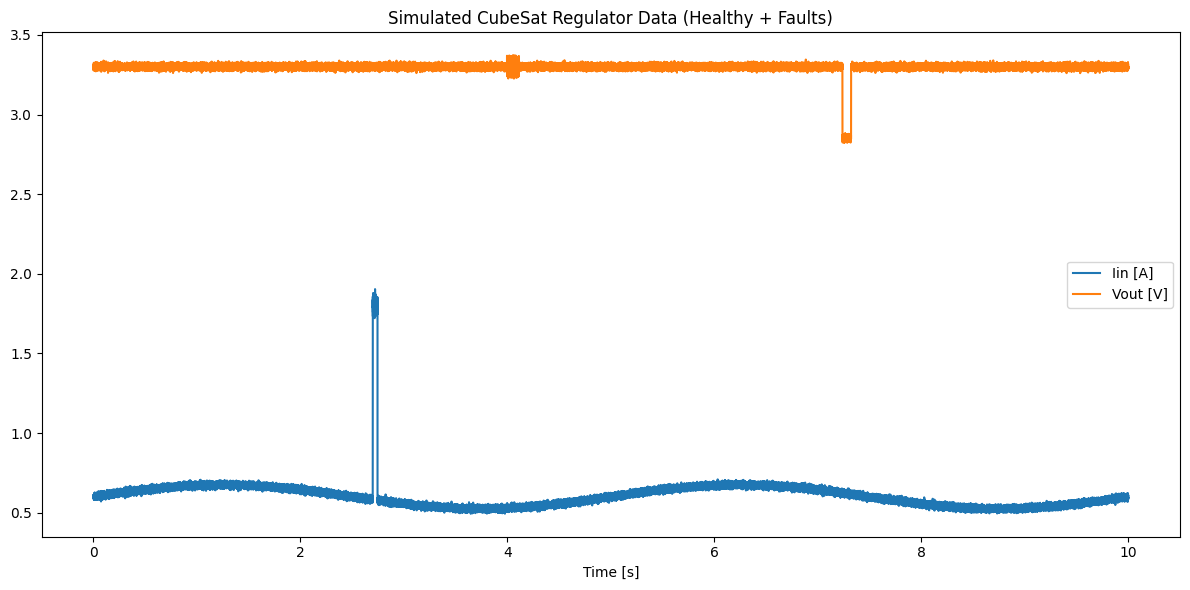

,time_s,Vin_V,Iin_A,Vout_V,Iout_A,Temp_C,fault_label
0,0.0000,5.0,0.591800,3.283709,0.794465,30.000000,0
1,0.0001,5.0,0.588917,3.302448,0.787875,30.000001,0
2,0.0002,5.0,0.610842,3.293902,0.812603,30.000003,0
3,0.0003,5.0,0.597934,3.293202,0.799133,30.000004,0
4,0.0004,5.0,0.595276,3.303408,0.794390,30.000005,0
5,0.0005,5.0,0.606758,3.303824,0.806389,30.000006,0
6,0.0006,5.0,0.600844,3.294470,0.801965,30.000008,0
7,0.0007,5.0,0.605988,3.301130,0.806104,30.000009,0
8,0.0008,5.0,0.605753,3.303620,0.805380,30.000010,0
9,0.0009,5.0,0.612025,3.296403,0.813382,30.000011,0


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Simulation parameters
# -----------------------------
fs = 10000          # 10 kHz sampling
duration_s = 10     # 10 seconds of data
N = fs * duration_s
t = np.arange(N) / fs

# -----------------------------
# Healthy baseline values
# -----------------------------
Vin_nom = 5.0                       # input voltage [V]
Vout_nom = 3.3                      # output voltage [V]
eff_nom = 0.88                      # nominal efficiency
load_current_mean = 0.8             # average output current [A]
temp_base = 30                      # °C

# -----------------------------
# Generate healthy signals
# -----------------------------
# Slow load variation (simulate real satellite bus variation)
load_current = load_current_mean + 0.1*np.sin(2*np.pi*0.2*t)  # 0.2 Hz breathing

# Noise terms (sensor + ripple)
noise_v = np.random.normal(0, 0.01, N)
noise_i = np.random.normal(0, 0.01, N)

# Core signals
Iout = load_current + noise_i
Vout = Vout_nom + noise_v
Pin  = (Vout * Iout) / eff_nom
Iin  = Pin / Vin_nom + noise_i*0.2

Temp = temp_base + 0.2*np.sin(2*np.pi*0.01*t)  # slow thermal drift

# -----------------------------
# Fault injection (simulated SEL-like events)
# -----------------------------
fault_labels = np.zeros(N, dtype=int)  # 0=healthy, 1=fault

def inject_fault(start_ms, duration_ms, mode="current_surge"):
    start = int(start_ms * fs / 1000)
    end = int((start_ms + duration_ms) * fs / 1000)
    end = min(end, N)
    fault_labels[start:end] = 1
    if mode == "current_surge":
        Iin[start:end] *= np.random.uniform(2.5, 3.5)
    elif mode == "voltage_droop":
        Vout[start:end] -= np.random.uniform(0.4, 0.7)
    elif mode == "ripple_increase":
        ripple = 0.05 * np.sin(2*np.pi*800*t[start:end])
        Vout[start:end] += ripple
    elif mode == "temp_rise":
        Temp[start:end] += np.random.uniform(5, 12)

# Inject multiple random faults
np.random.seed(42)
for _ in range(5):
    start_ms = np.random.uniform(1000, duration_s*1000 - 1000)
    duration_ms = np.random.uniform(30, 120)  # short transient (30–120 ms)
    mode = np.random.choice(["current_surge", "voltage_droop",
                             "ripple_increase", "temp_rise"])
    inject_fault(start_ms, duration_ms, mode)

# -----------------------------
# Pack into DataFrame
# -----------------------------
df = pd.DataFrame({
    "time_s": t,
    "Vin_V": Vin_nom,
    "Iin_A": Iin,
    "Vout_V": Vout,
    "Iout_A": Iout,
    "Temp_C": Temp,
    "fault_label": fault_labels
})

# -----------------------------
# Quick visualization
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df["time_s"], df["Iin_A"], label="Iin [A]")
plt.plot(df["time_s"], df["Vout_V"], label="Vout [V]")
plt.title("Simulated CubeSat Regulator Data (Healthy + Faults)")
plt.xlabel("Time [s]")
plt.legend()
plt.tight_layout()
plt.show()

df.head(10)


In [2]:
df.to_csv("cubesat_regulator_raw.csv", index=False)